In [1]:
# CELL 1: CONFIGURATION
# ============================================================================
# Edit only the values in this section!

PROJECT_ROOT = '/home/alya/phyloDCA_public/'
DATASET_NAME = 'betaLac'  # Change this for different datasets

# File names (these should exist in data_betaLac/extant_msa/)
MSA_FILENAME = 'PF13354_noinsert_max19gaps_nodupl_noclose_BetaLact.faa'

# File names (these should exist in data_betaLac/)
PARAMS_FILENAME = 'Parameters_conv_Matteo_pc_BetaLact.dat'

# Sampling parameters
NUM_SAMPLES = 1000  # How many sequences to sample from posterior
NUM_TOP_CANDIDATES = 10  # How many best ones to keep
MCMC_TEMPERATURE = 0.2  # 0-1, lower = closer to MAP

print("✓ Configuration loaded")

✓ Configuration loaded


In [2]:
# CELL 2: IMPORTS & SETUP
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Add project to path
sys.path.insert(0, PROJECT_ROOT)

# Import helpers
from utils import *

# Setup all paths
paths = setup_paths(PROJECT_ROOT, DATASET_NAME)
print(f"\nProject structure:")
print(f"  Data directory: {paths['data']}")
print(f"  Output ASR: {paths['output_asr']}")
print(f"  Output candidates: {paths['output_candidates']}")

Folder 'gradient_figs/' already exists.
✓ Paths configured and output directories created

Project structure:
  Data directory: /home/alya/phyloDCA_public/data_betaLac/
  Output ASR: /home/alya/phyloDCA_public/output_betaLac_asr/
  Output candidates: /home/alya/phyloDCA_public/output_betaLac_candidates/


In [3]:
# --- IGNORE --- OR INSTALL DEPENDENCIES
# !pip install --upgrade pip
# !pip install ete3
# !pip install matplotlib
# !pip install biopython
# !pip install seaborn
# !pip install pandas
# !pip install hmmer
# !pip install distinctipy
# !pip install torch
# !pip install tqdm
# !pip install fasttree
# !pip install scikit-learn
# !pip install numba

In [4]:
# CELL 3: LOAD DATA
# This loads your MSA and DCA parameters

msa_file = f"{paths['msa']}{MSA_FILENAME}"
params_file = f"{paths['data']}{PARAMS_FILENAME}"

msa_array, headers, fields, couplings = load_data(msa_file, params_file)
print(f"\nData summary:")
print(f"  MSA: {len(headers)} sequences × {msa_array.shape[1]} sites")
print(f"  DCA model ready")

Loading MSA from: /home/alya/phyloDCA_public/data_betaLac/extant_msa/PF13354_noinsert_max19gaps_nodupl_noclose_BetaLact.faa
  ✓ Loaded 18334 sequences of length 202
Loading DCA parameters from: /home/alya/phyloDCA_public/data_betaLac/Parameters_conv_Matteo_pc_BetaLact.dat
Error loading parameters as bmDCA format: "The chosen alphabet is incompatible with the Multi-Sequence Alignment. The missing tokens are: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']. Current alphabet: -ACDEFGHIKLMNPQRSTVWY"
Trying FraZ format...
L: 202
Couplings verified as symmetric.
  ✓ Loaded fields shape (202, 21), couplings shape (202, 202, 21, 21)

Data summary:
  MSA: 18334 sequences × 202 sites
  DCA model ready


In [5]:
# CELL 4: OPTIONAL - CLEAN MSA AND INFER TREE
# Only run this cell if you want to clean your MSA and infer a new tree
# Set CLEAN_DATA = True to regenerate cleaned data and tree
# Otherwise, cleaned data from cleaned_data_and_inferred_tree/ will be used

CLEAN_DATA = False  # Set to True to clean MSA and infer tree from scratch

if CLEAN_DATA:
    print("Cleaning MSA and inferring phylogenetic tree...")
    print("This may take several minutes...\n")
    
    from utils.alignmentAndTreeSetUp import cleanAlignmentAndTree
    
    # Setup output directories
    output_base = 'cleaned_data_and_inferred_tree/'
    tree_save_folder = f'{output_base}tree/'
    alignment_save_folder = f'{output_base}alignment/'
    figure_save_folder = f'{output_base}figures/'
    
    # Run cleaning and tree inference
    cleanAlignmentAndTree(
        msa_file,
        tree_save_folder=tree_save_folder,
        alignment_save_folder=alignment_save_folder,
        family_name=DATASET_NAME,
        prune=False,
        leaf_number=300,
        length_threshold=1e-6,
        save_folder=figure_save_folder
    )
    
    # Set paths to cleaned data
    msa_file = f'{alignment_save_folder}{DATASET_NAME}_collapsed.fasta'
    tree_file = f'{tree_save_folder}{DATASET_NAME}tree_collapsed_noonlychild_midpointrooted.nwk'
    
    print(f"\n✓ Cleaned MSA saved to: {msa_file}")
    print(f"✓ Inferred tree saved to: {tree_file}")
    print("✓ Updated to use cleaned data and inferred tree")
    
else:
    print("Using existing cleaned data and tree from: cleaned_data_and_inferred_tree/\n")
    
    # Use pre-existing cleaned data
    msa_file = 'cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta'
    tree_file = 'cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk'
    
    print(f"  MSA: {msa_file}")
    print(f"  Tree: {tree_file}")

Using existing cleaned data and tree from: cleaned_data_and_inferred_tree/

  MSA: cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta
  Tree: cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk


In [6]:
# CELL 5: VERIFY FILES EXIST
# Check that all required files are present before running ASR

print("\nVerifying all required files exist...\n")

required_files = {
    'MSA': msa_file,
    'Tree': tree_file,
    'DCA Parameters': params_file
}

all_good = True
for name, filepath in required_files.items():
    exists = os.path.exists(filepath)
    status = "✓" if exists else "✗"
    print(f"  {status} {name}: {filepath}")
    if not exists:
        all_good = False

if not all_good:
    raise FileNotFoundError("\n✗ Some required files are missing! Check paths above.")

print("\n✓ All files verified and ready!")


Verifying all required files exist...

  ✓ MSA: cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta
  ✓ Tree: cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk
  ✓ DCA Parameters: /home/alya/phyloDCA_public/data_betaLac/Parameters_conv_Matteo_pc_BetaLact.dat

✓ All files verified and ready!



Running ASR pipeline...
  MSA: cleaned_data_and_inferred_tree/alignment/betaLac_collapsed.fasta
  Tree: cleaned_data_and_inferred_tree/tree/betaLactree_collapsed_noonlychild_midpointrooted.nwk


RUNNING ASR FOR: betaLac_collapsed

1. Inferring mutation rate (mu)...


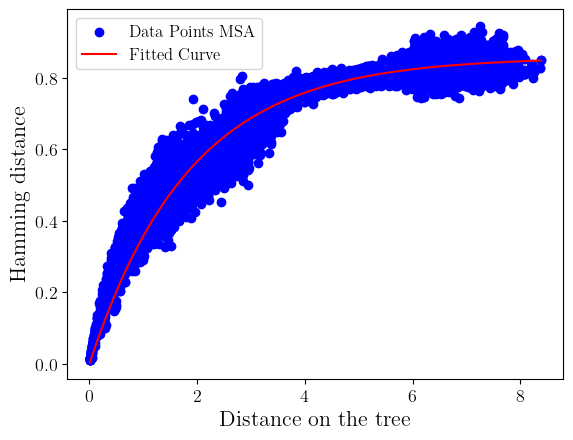

Fitted parameters: a = 0.8577821733281042, mu = 0.5395562000397345. Fitted on 1000 leaves. Fitted curve is d_hamming = 0.8577821733281042 * (1 - exp(-0.5395562000397345 * d_tree))
   ✓ mu = 0.53956

2. Loading sequences and tree...
   ✓ Loaded 15801 leaf sequences

3. Computing site-wise amino acid frequencies...
   ✓ Computed frequencies for 202 sites

4. Computing ancestral state posteriors...
   Using device: cuda
Processing 202 sites with batch_size=64, use_jit=True
Testing JIT compilation...
JIT compilation successful!
Processing batch 1/4
   ✓ Posteriors computed: shape torch.Size([202, 21])

✓ Saved posteriors to: /home/alya/phyloDCA_public/output_betaLac_asr/betaLac_collapsed_posteriors.npy
✓ ASR completed in 127.4 seconds



In [7]:
# CELL 6: RUN ANCESTRAL STATE RECONSTRUCTION
# This is the main computation - sit back and wait!

print(f"\nRunning ASR pipeline...")
print(f"  MSA: {msa_file}")
print(f"  Tree: {tree_file}\n")

posteriors, seq_name = run_asr_pipeline(
    msa_file=msa_file,
    tree_file=tree_file,
    output_dir=paths['output_asr']
)

In [ ]:
# CELL 7: SAMPLE AND RANK SEQUENCES
# Generate candidate sequences from the ancestral probability distribution

candidates, sampled_msa, sampled_msa_original = sample_and_rank_sequences(
    posteriors=posteriors,
    num_samples=NUM_SAMPLES,
    num_top=NUM_TOP_CANDIDATES,
    fields=fields,
    couplings=couplings,
    temperature=MCMC_TEMPERATURE
)

print(f"Top candidates:")
for cand in candidates[:5]:
    source = cand.get('source', '?')
    print(f"  Rank {cand['rank']}: {source:15s} | Score = {cand['score']:.2f}")

Sampling 1000 sequences from posterior...
   ✓ Generated MSA shape: (1000, 202)

Applying MCMC reshuffling (T=0.2)...
Site probabilities are computed as entropy(site), non normalized
   ✓ MCMC reshuffling completed

Ranking sequences by posterior likelihood...
✓ Top 10 candidates ranked from both sets

Top candidates:
  Rank 1: MCMC_reshuffled | Score = -57.21
  Rank 2: MCMC_reshuffled | Score = -57.60
  Rank 3: MCMC_reshuffled | Score = -57.91
  Rank 4: MCMC_reshuffled | Score = -58.17
  Rank 5: MCMC_reshuffled | Score = -58.25


In [ ]:
# CELL 8: SAVE RESULTS TO FASTA
# Export your sequences for further analysis

output_fasta = f"{paths['output_candidates']}{seq_name}_top_candidates.fasta"

save_candidates_to_fasta(
    candidates=candidates,
    posteriors=posteriors,
    msa_original=sampled_msa_original,
    msa_reshuffled=sampled_msa,
    output_file=output_fasta
)

print(f"\n{'='*60}")
print(f"DONE! Your results are in:")
print(f"  {output_fasta}")
print(f"{'='*60}")


Saving candidates:
  - 1 MAP sequence
  - 0 from ASR posterior
  - 10 from MCMC reshuffled

✓ Saved 11 total sequences to: /home/alya/phyloDCA_public/output_betaLac_candidates/betaLac_collapsed_top_candidates.fasta


DONE! Your results are in:
  /home/alya/phyloDCA_public/output_betaLac_candidates/betaLac_collapsed_top_candidates.fasta


In [10]:
# CELL 9: MISCELLANEOUS
# Additional analyses and visualization options

# Use the samplerOnTrees function to sample from a WT sequence and a tree, generating sequences at the leaves and internal nodes. This function can be used to simulate evolutionary processes along a phylogenetic tree.
# Gibbs DCA

# Computing CDE
